# Step 2: Review Quality Filter (Model 1: XGBoost)
**Role: Person A (Data & ML Engineer)**

Notebook ini berisi langkah-langkah **Step 2** dalam proyek ABSA + Review Quality Filter:
1. **Load Data**: Membaca dataset Parquet bersih (`reviews_clean.parquet`) hasil Preprocessing (Step 1) dan menggabungkannya kembali dengan teks asli untuk kebutuhan ekstraksi fitur kapital.
2. **Feature Engineering**: Membuat 7 fitur input untuk klasifikasi kualitas ulasan.
3. **Data Splitting**: Membagi dataset menjadi 80% Training dan 20% Testing.
4. **Model Training**: Melatih model **XGBoost Classifier** dan **Random Forest** (sebagai baseline).
5. **Model Evaluation**: Mengevaluasi model menggunakan metrik Accuracy, Precision, Recall, F1-Score, ROC-AUC, dan Confusion Matrix.
6. **Export Output**: Melakukan prediksi kualitas pada seluruh ulasan, memfilter hanya ulasan dengan `is_trusted = 1` (Trusted), lalu mengekspor hasilnya ke **`trusted_reviews.csv`**.

---
## 1. Import Libraries & Setup Spark Session

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Append parent directory to sys.path to allow config import
sys.path.append(os.path.abspath('..'))
import config

# Setup PySpark Session
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, length, size, split, when, regexp_replace

spark = SparkSession.builder \
    .appName("AmazonQualityFilterTraining") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.driver.extraJavaOptions", "-Djava.security.manager=allow") \
    .getOrCreate()

print("Spark Session initialized successfully!")

Spark Session initialized successfully!


---
## 2. Load Data & Join with Raw Text
Untuk menghitung rasio huruf kapital (`caps_ratio`) dengan akurat, kita memerlukan teks asli yang belum di-lowercase. Kita akan men-join data bersih Step 1 dengan kolom teks asli dari dataset mentah berdasarkan `review_id`.

In [3]:
print("Loading preprocessed Parquet data...")
df_clean = spark.read.parquet(config.CLEANED_PARQUET_PATH)

print("Loading raw text data for capitalization analysis...")
df_raw = spark.read.csv(
    config.RAW_TSV_PATH, 
    sep="\t", 
    header=True, 
    inferSchema=True
).select("review_id", col("review_body").alias("review_body_raw"))

# Join data bersih dengan data mentah untuk mengambil teks asli
df_joined = df_clean.join(df_raw, on="review_id", how="inner")
print(f"Total baris data setelah digabungkan: {df_joined.count():,}")

Loading preprocessed Parquet data...
Loading raw text data for capitalization analysis...
Total baris data setelah digabungkan: 1,239,196


---
## 3. Feature Engineering
Kita akan mengekstrak 7 fitur input dan 1 target label biner (`is_trusted`):

In [4]:
print("Mengolah fitur-fitur baru...")

# 1. review_length (panjang karakter ulasan bersih)
df_features = df_joined.withColumn("review_length", length(col("review_body")))

# 2. word_count (jumlah kata ulasan bersih)
df_features = df_features.withColumn("word_count", size(split(col("review_body"), "\\s+")))

# 3. quality_ratio (sudah ada dari Preprocessing: helpful_votes / (total_votes + 1))
# Dipertahankan tanpa perubahan

# 4. is_verified (verified_purchase Y/N -> 1/0)
df_features = df_features.withColumn(
    "is_verified", 
    when((col("verified_purchase") == "Y") | (col("verified_purchase") == "true"), 1).otherwise(0)
)

# 5. is_vine (vine Y/N -> 1/0)
df_features = df_features.withColumn(
    "is_vine", 
    when((col("vine") == "Y") | (col("vine") == "true"), 1).otherwise(0)
)

# 6. exclamation_count (jumlah tanda seru '!' pada teks asli)
df_features = df_features.withColumn(
    "exclamation_count", 
    length(col("review_body_raw")) - length(regexp_replace(col("review_body_raw"), "!", ""))
)
# Penanganan null pada tanda seru
df_features = df_features.withColumn(
    "exclamation_count", 
    when(col("exclamation_count").isNull(), 0).otherwise(col("exclamation_count"))
)

# 7. caps_ratio (jumlah huruf kapital / total karakter teks asli)
df_features = df_features.withColumn(
    "caps_count", 
    length(col("review_body_raw")) - length(regexp_replace(col("review_body_raw"), "[A-Z]", ""))
)
df_features = df_features.withColumn(
    "caps_ratio", 
    when((col("caps_count").isNotNull()) & (length(col("review_body_raw")) > 0), 
         col("caps_count") / length(col("review_body_raw"))).otherwise(0.0)
)

# Target Label: is_trusted = 1 jika quality_ratio > 0.5, else 0
df_features = df_features.withColumn(
    "is_trusted", 
    when(col("quality_ratio") > 0.5, 1).otherwise(0)
)

print("Feature engineering selesai!")

Mengolah fitur-fitur baru...
Feature engineering selesai!


---
## 4. Konversi Data ke Pandas untuk ML Training
Karena model XGBoost dan Random Forest dari scikit-learn melatih data dalam memori, kita konversi DataFrame Spark ke Pandas DataFrame.

In [9]:
feature_cols = feature_cols = ["review_length", "word_count", "is_verified", "is_vine", "exclamation_count", "caps_ratio"]
target_col = "is_trusted"

print("Mengonversi dataset ke Pandas (ini memerlukan waktu beberapa menit)...")
# Ambil kolom fitur, target, dan kolom penting lainnya
pdf = df_features.select(feature_cols + [target_col] + ["review_id", "product_id", "review_body", "star_rating"]).toPandas()

print(f"Ukuran dataset Pandas: {pdf.shape}")
pdf[feature_cols + [target_col]].head(5)

Mengonversi dataset ke Pandas (ini memerlukan waktu beberapa menit)...
Ukuran dataset Pandas: (1239196, 11)


,review_length,word_count,is_verified,is_vine,exclamation_count,caps_ratio,is_trusted
0,97,14,1,0,1,0.048544,0
1,129,23,1,0,0,0.007752,1
2,389,65,0,0,0,0.050847,1
3,650,120,1,0,0,0.030769,0
4,1905,357,1,0,1,0.024785,1


---
## 5. Split Dataset (80% Train, 20% Test)

In [10]:
from sklearn.model_selection import train_test_split

X = pdf[feature_cols]
y = pdf[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Jumlah data training: {X_train.shape[0]:,}")
print(f"Jumlah data testing: {X_test.shape[0]:,}")
print(f"Rasio kelas data training:\n{y_train.value_counts(normalize=True)}")

Jumlah data training: 991,356
Jumlah data testing: 247,840
Rasio kelas data training:
is_trusted
0    0.860914
1    0.139086
Name: proportion, dtype: float64


---
## 6. Training Model
Kita akan melatih dua model:
1. **XGBoost Classifier** (Model Utama)
2. **Random Forest Classifier** (Model Baseline)

In [13]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import pickle

# Hitung scale_pos_weight untuk menangani class imbalance
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"scale_pos_weight yang digunakan: {scale_pos_weight:.2f}")

# 1. Inisiasi & Latih Model Utama (XGBoost)
print("Training XGBoost Classifier...")
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)
xgb_model.fit(X_train, y_train)
print("XGBoost training complete.")

# 2. Inisiasi & Latih Model Baseline (Random Forest)
print("\nTraining Random Forest Classifier (Baseline)...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf_model.fit(X_train, y_train)
print("Random Forest training complete.")

scale_pos_weight yang digunakan: 6.19
Training XGBoost Classifier...
XGBoost training complete.

Training Random Forest Classifier (Baseline)...
Random Forest training complete.


---
## 7. Model Evaluation
Mengevaluasi kedua model pada test set menggunakan Accuracy, Precision, Recall, F1-Score, dan ROC-AUC.

In [14]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_recall_fscore_support

# Prediksi hasil
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Tampilkan Laporan Klasifikasi
print("==================== XGBOOST CLASSIFIER EVALUATION ====================")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

print("\n==================== RANDOM FOREST EVALUATION (BASELINE) ====================")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

==================== XGBOOST CLASSIFIER EVALUATION ====================
              precision    recall  f1-score   support

           0       0.94      0.72      0.81    213369
           1       0.29      0.72      0.42     34471

    accuracy                           0.72    247840
   macro avg       0.62      0.72      0.62    247840
weighted avg       0.85      0.72      0.76    247840

ROC-AUC Score: 0.7947

==================== RANDOM FOREST EVALUATION (BASELINE) ====================
              precision    recall  f1-score   support

           0       0.94      0.68      0.79    213369
           1       0.28      0.75      0.40     34471

    accuracy                           0.69    247840
   macro avg       0.61      0.72      0.60    247840
weighted avg       0.85      0.69      0.74    247840

ROC-AUC Score: 0.7928


### 7.1. Visualisasi Confusion Matrix
Menggambarkan Confusion Matrix side-by-side menggunakan seaborn.

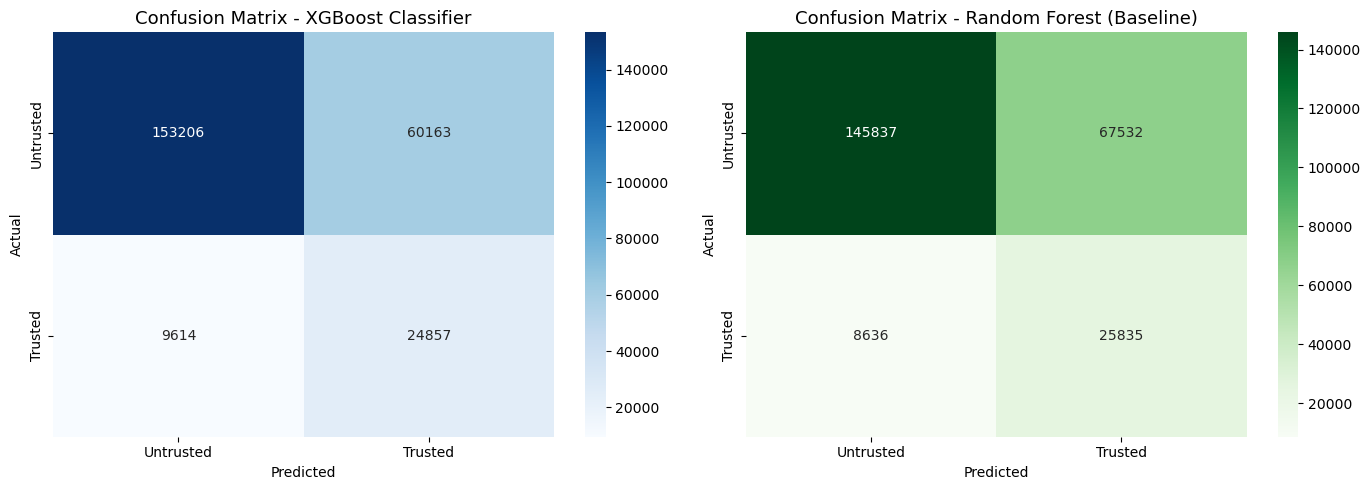

In [15]:
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot XGBoost
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Untrusted", "Trusted"], yticklabels=["Untrusted", "Trusted"])
axes[0].set_title("Confusion Matrix - XGBoost Classifier", fontsize=13)
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# Plot Random Forest
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["Untrusted", "Trusted"], yticklabels=["Untrusted", "Trusted"])
axes[1].set_title("Confusion Matrix - Random Forest (Baseline)", fontsize=13)
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.show()

### 7.2. Visualisasi Kurva ROC-AUC

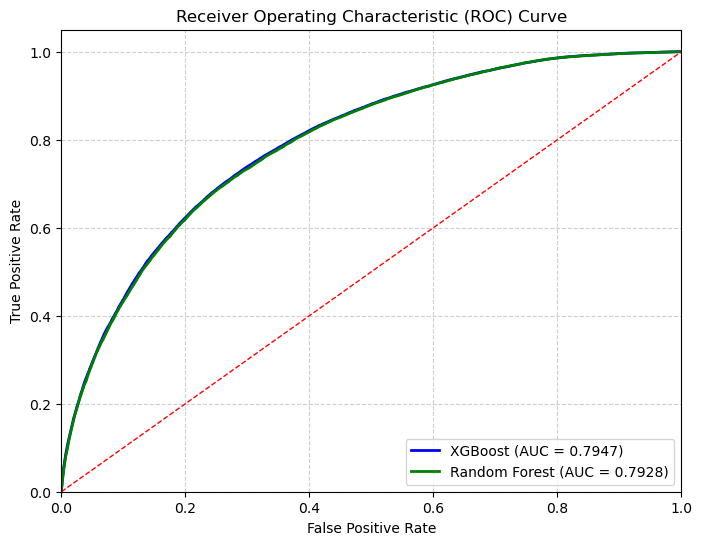

In [16]:
from sklearn.metrics import roc_curve, auc

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='blue', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

---
### 7.3. Feature Importance (Faktor Penentu Kualitas Ulasan)
Melihat fitur mana saja yang paling memengaruhi model XGBoost dalam mengidentifikasi apakah sebuah ulasan dikategorikan sebagai *Trusted* (1) atau *Untrusted* (0).

C:\Users\pearl\AppData\Local\Temp\ipykernel_29084\4291988540.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


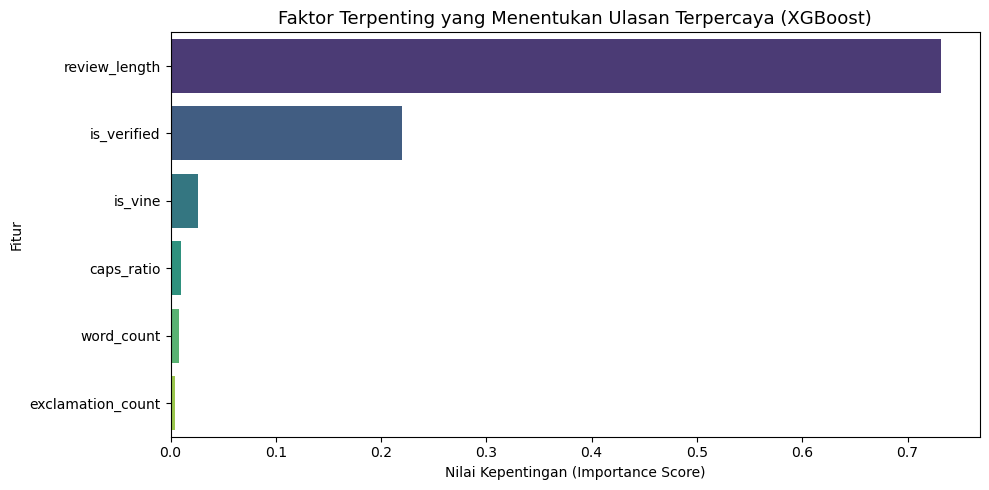

In [17]:
# Ambil nilai feature importance dari model XGBoost
importances = xgb_model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualisasi
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Faktor Terpenting yang Menentukan Ulasan Terpercaya (XGBoost)', fontsize=13)
plt.xlabel('Nilai Kepentingan (Importance Score)')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

---
## 8. Menyimpan Model Terlatih (Pickle)

In [18]:
# Tentukan path penyimpanan model
print(f"Menyimpan model XGBoost ke: {config.MODEL_XGBOOST_PATH}")
with open(config.MODEL_XGBOOST_PATH, "wb") as f:
    pickle.dump(xgb_model, f)

print(f"Menyimpan model Random Forest ke: {config.MODEL_RF_PATH}")
with open(config.MODEL_RF_PATH, "wb") as f:
    pickle.dump(rf_model, f)

print("Model berhasil disimpan!")

Menyimpan model XGBoost ke: d:\big data\final project\ABSA project\models\quality_filter_xgboost.pkl
Menyimpan model Random Forest ke: d:\big data\final project\ABSA project\models\quality_filter_rf.pkl
Model berhasil disimpan!


---
## 9. Ekspor Ulasan Terpercaya (`trusted_reviews.csv`)
Gunakan model XGBoost untuk memprediksi label `is_trusted` dan `trust_probability` pada seluruh baris ulasan di dataset, lalu saring baris yang memiliki `is_trusted = 1` untuk diekspor sebagai file CSV.

In [19]:
print("Melakukan prediksi pada seluruh dataset...")
# Lakukan prediksi is_trusted pada seluruh data Pandas
pdf["is_trusted_predicted"] = xgb_model.predict(X)
pdf["trust_probability"] = xgb_model.predict_proba(X)[:, 1]

# Filter data: ambil hanya ulasan dengan prediksis is_trusted = 1
pdf_trusted = pdf[pdf["is_trusted_predicted"] == 1]

print(f"Total ulasan tepercaya hasil filter: {pdf_trusted.shape[0]:,} dari total {pdf.shape[0]:,} ulasan.")

# Tentukan path file output CSV
output_csv_path = os.path.join(config.OUTPUTS_DIR, "trusted_reviews.csv")
print(f"Menyimpan hasil ke: {output_csv_path}")

# Pilih kolom-kolom utama untuk dikirim ke ABSA (Step 3)
pdf_trusted_clean = pdf_trusted[["review_id", "product_id", "review_body", "star_rating", "trust_probability"]]
pdf_trusted_clean.to_csv(output_csv_path, index=False, encoding="utf-8")

print("Ekspor CSV berhasil selesai!")
pdf_trusted_clean.head(5)

Melakukan prediksi pada seluruh dataset...
Total ulasan tepercaya hasil filter: 425,803 dari total 1,239,196 ulasan.
Menyimpan hasil ke: d:\big data\final project\ABSA project\outputs\trusted_reviews.csv
Ekspor CSV berhasil selesai!


,review_id,product_id,review_body,star_rating,trust_probability
2,R1007TU9E6ICBX,B007IHF5QM,"with two caveats, this mount worked great for ...",4,0.747802
3,R100FZKQ3DH330,B001YSAV6A,i bought this because i needed something child...,5,0.680529
4,R100GHF5YMF7F2,B000EPNDEG,i never thought i'd buy an ipod (or any mp3-ty...,4,0.848870
5,R100HEBRKWJOHC,B00HFA91IA,if you're looking to enter the world of tube a...,4,0.742265
8,R100KV9RSQBWU,B000H0QDCC,i've had the 30gb zune for about a month at ti...,5,0.610891


---
## 10. Penutupan Sesi Spark

In [20]:
spark.stop()
print("Spark Session stopped.")

Spark Session stopped.
